# Stroke Prediction

Podstawowa struktura notebooka do projektu klasyfikacji ryzyka udaru.

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Cel i zakres

- Zdefiniuj problem i zmienną celu (`stroke`).
- Opisz krótko dane i metryki, których będziesz używać.

## 2. Środowisko i konfiguracja

- Opisz użyte biblioteki i wersje.
- Zapisz założenia dotyczące powtarzalności (np. random seed).
- Dodaj krótką notatkę o strukturze notebooka.

## 3. Wczytanie i opis danych

- Źródło danych.
- Wymiary zbioru i opis kolumn.
- Typy zmiennych (numeryczne / kategoryczne).
- Krótki komentarz o jakości danych.

In [59]:
df = pd.read_csv('../data/healthcare-dataset-stroke-data.csv', index_col=0)

df.shape

(5110, 11)

Dane zostały wzięte z ogólno dostępnego zbioru danych na kaggle - *Stroke Prediction Dataset*. Zbiór danych zawiera 11 atrybutów (z czego jedna opisuje czy pacjent miał zawał) oraz 5110 pacjentów.

In [60]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


| Nazwa kolumny | Opis | Rodzaj danych |
|---|---|---|
| `gender` | Płeć pacjenta | Kategoryczna |
| `age` | Wiek pacjenta | Numeryczna |
| `hypertension` | Czy pacjent ma nadciśnienie | Kategoryczna (binarna) |
| `heart_disease` | Czy pacjent ma jakieś choroby serca | Kategoryczna (binarna) |
| `ever_married` | Czy pacjent był/jest w małżeństwie | Kategoryczna |
| `work_type` | Rodzaj pracy wykonywany | Kategoryczna |
| `Residence_type` | Miejsce zamieszkania | Kategoryczna |
| `avg_glucose_level` | Średni poziom glukozy we krwi | Numeryczna |
| `bmi` | 'Body mass index' | Numeryczna |
| `smoking_status` | Relacja pacjenta z papierosami | Kategoryczna |


In [61]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

<Axes: xlabel='stroke', ylabel='count'>

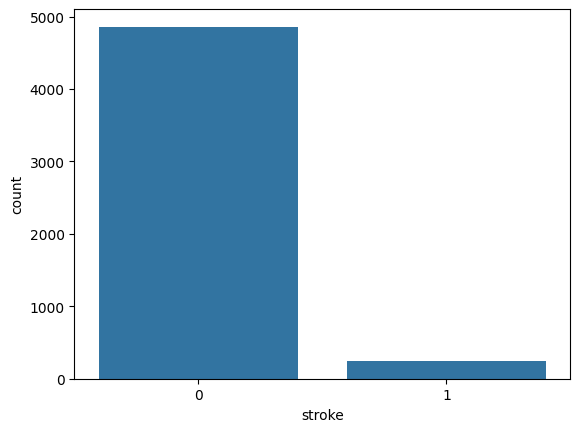

In [62]:
sns.countplot(df, x=df.stroke)

Zbiór danych jest silnie niezbalansowany, około 5% danych to przypadki pozytywne (zawał wystąpił). Do jak najleszego wytrenowania modelu będzie dobrze zrobiony podział danych.

## 4. Czyszczenie i sanity check danych

- Braki danych i strategia ich uzupełniania.
- Outliery

In [63]:
missing_values = df.isnull().sum()
missing_values

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Sprawdźmy jak wygląda brak BMI w kontekście tego czy ktoś miał udar czy nie

Procentowy rozklad udaru dla brakow BMI (0 = brak braku, 1 = brak BMI):


stroke,0,1
bmi_missing,,
0,95.74,4.26
1,80.10,19.90


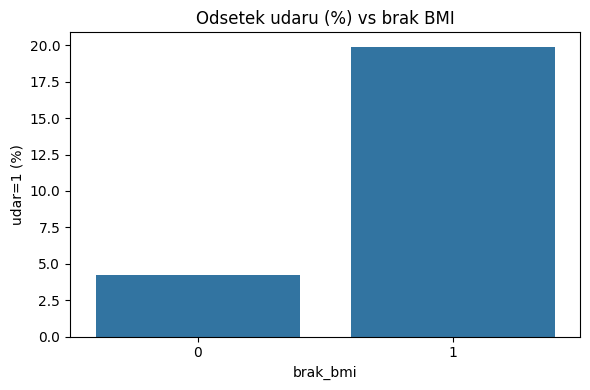

In [64]:
df_eda = df.copy()
df_eda["bmi_missing"] = df_eda["bmi"].isna().astype(int)

missing_vs_target = pd.crosstab(
    df_eda["bmi_missing"],
    df_eda["stroke"],
    normalize="index"
) * 100

print("Procentowy rozklad udaru dla brakow BMI (0 = brak braku, 1 = brak BMI):")
display(missing_vs_target.round(2))

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    x=missing_vs_target.index.astype(str),
    y=missing_vs_target[1].values
)
ax.set_title("Odsetek udaru (%) vs brak BMI")
ax.set_xlabel("brak_bmi")
ax.set_ylabel("udar=1 (%)")
plt.tight_layout()
plt.show()

20% przypadków z udarem to osoby, które nie mają BMI w danych. Brakujące dane w kolumnie BMI zastąpimy medianą zbioru, ponieważ model mógłby się nauczyć, że jeżeli ta kolumna jest pusta to mamy udar.

In [65]:
df.bmi = df.bmi.transform(lambda x: x.fillna(x.median()))

In [66]:
assert df.bmi.isnull().values.any() == False, "Kolumna 'bmi' zawiera brakujące wartości"

### Sprawdzenie czy nie mamy dzikich wartości w zbiorze danych

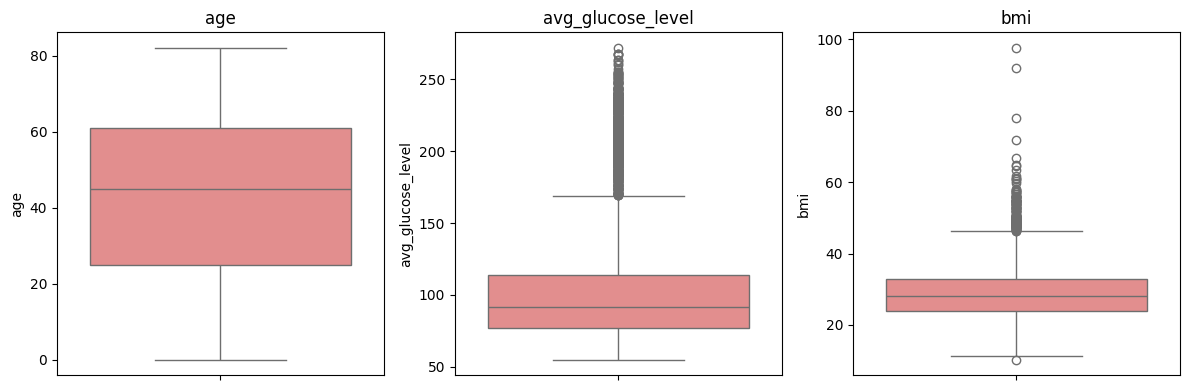

In [67]:
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

## 5. Eksploracyjna analiza danych (EDA)

- Rozkład zmiennej celu (`stroke`).
- Analiza cech względem celu.
- Korelacje i zależności między cechami.
- Najważniejsze obserwacje z EDA.

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_glucose_level'}>,
        <Axes: title={'center': 'bmi'}>]], dtype=object)

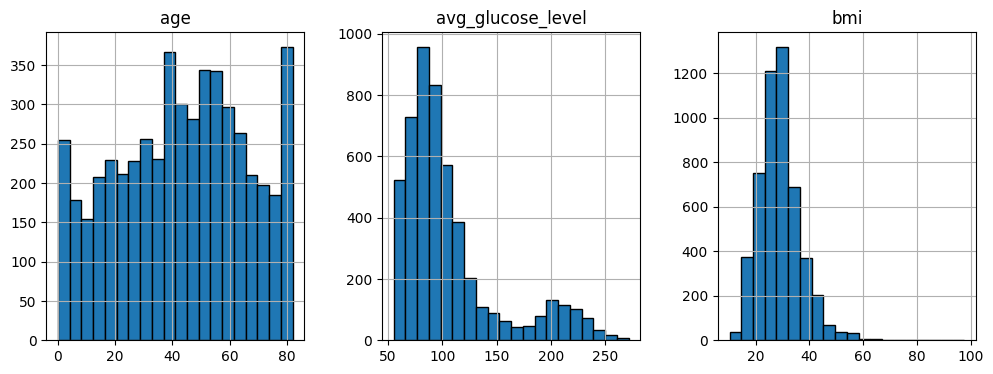

In [68]:
num_cols = ['age', 'avg_glucose_level', 'bmi']
df[num_cols].hist(figsize=(12, 4), bins=20, edgecolor='black', layout=(1,3))

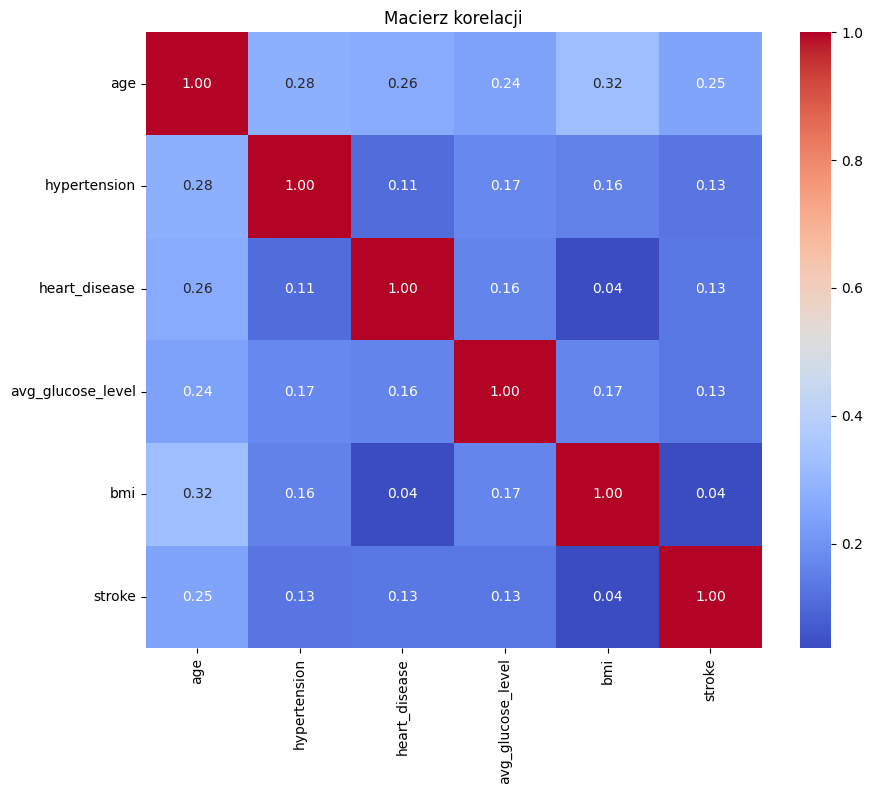

In [69]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Macierz korelacji")
plt.show()

Liczebnosci klas:


stroke
0    4861
1     249
Name: count, dtype: int64

Procenty klas:


stroke
0    95.13
1     4.87
Name: proportion, dtype: float64

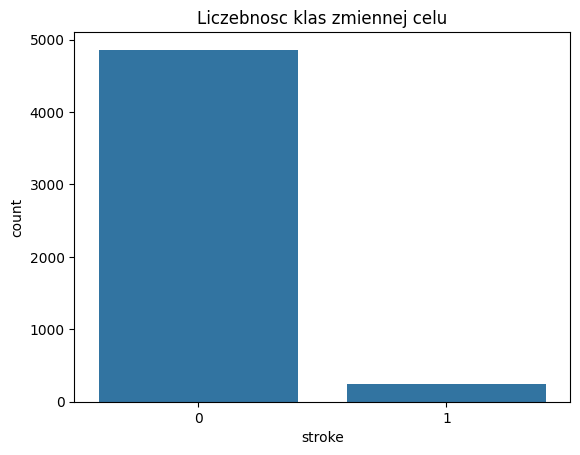

In [70]:
target_counts = df["stroke"].value_counts().sort_index()
target_pct = df["stroke"].value_counts(normalize=True).sort_index() * 100

print("Liczebnosci klas:")
display(target_counts)
print("Procenty klas:")
display(target_pct.round(2))

sns.countplot(data=df, x="stroke")
plt.title("Liczebnosc klas zmiennej celu")
plt.show()


gender -> odsetek udaru (%)


,odsetek_udaru_proc
gender,
Male,5.11
Female,4.71
Other,0.00


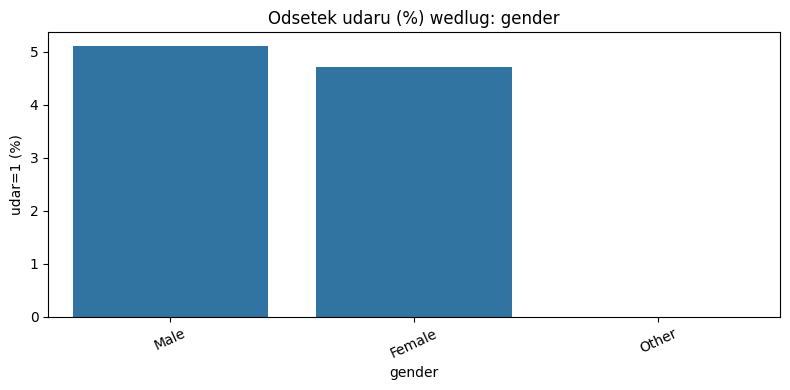


ever_married -> odsetek udaru (%)


,odsetek_udaru_proc
ever_married,
Yes,6.56
No,1.65


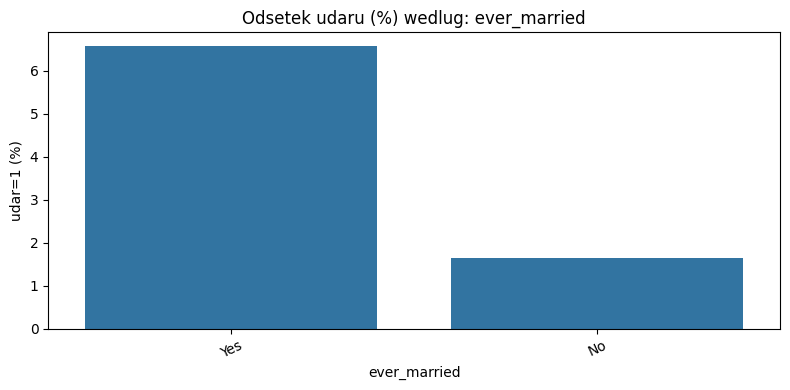


work_type -> odsetek udaru (%)


,odsetek_udaru_proc
work_type,
Self-employed,7.94
Private,5.09
Govt_job,5.02
children,0.29
Never_worked,0.00


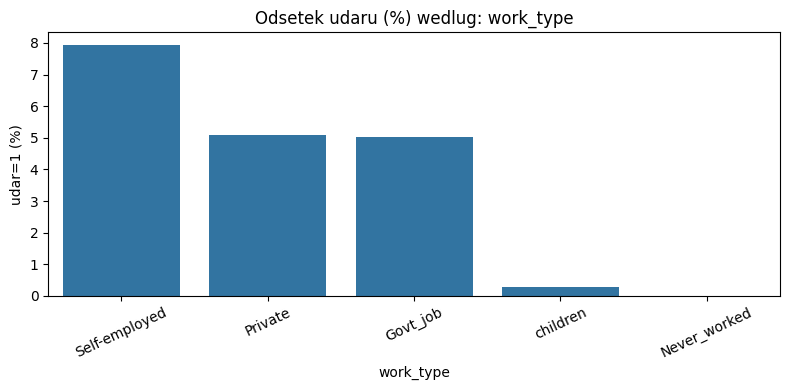


Residence_type -> odsetek udaru (%)


,odsetek_udaru_proc
Residence_type,
Urban,5.20
Rural,4.53


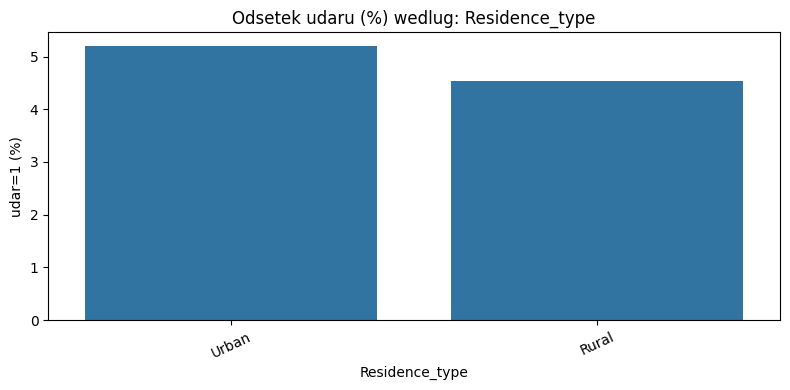


smoking_status -> odsetek udaru (%)


,odsetek_udaru_proc
smoking_status,
formerly smoked,7.91
smokes,5.32
never smoked,4.76
Unknown,3.04


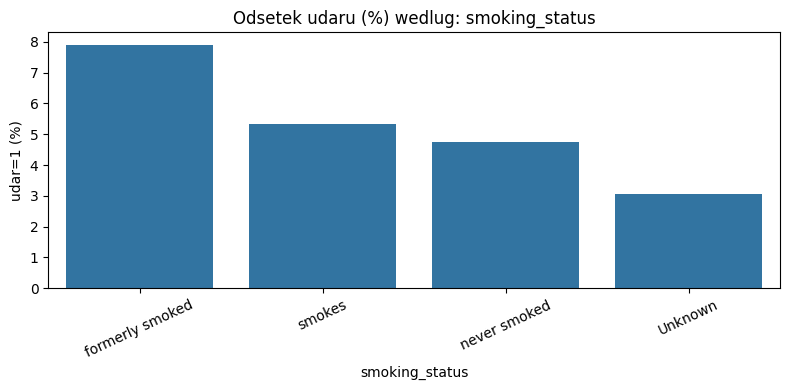

In [71]:
cat_cols_focus = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

for col in cat_cols_focus:
    rate = (
        df.groupby(col)["stroke"]
        .mean()
        .sort_values(ascending=False)
        * 100
    )

    print(f"\n{col} -> odsetek udaru (%)")
    display(rate.round(2).to_frame(name="odsetek_udaru_proc"))

    plt.figure(figsize=(8, 4))
    sns.barplot(x=rate.index.astype(str), y=rate.values)
    plt.title(f"Odsetek udaru (%) wedlug: {col}")
    plt.xlabel(col)
    plt.ylabel("udar=1 (%)")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

,liczebnosc,odsetek_udaru_proc
przedzial_wieku,,
0-18,916,0.22
19-30,654,0.00
31-45,1048,1.05
46-60,1188,4.97
61-75,839,9.65
76+,465,20.65


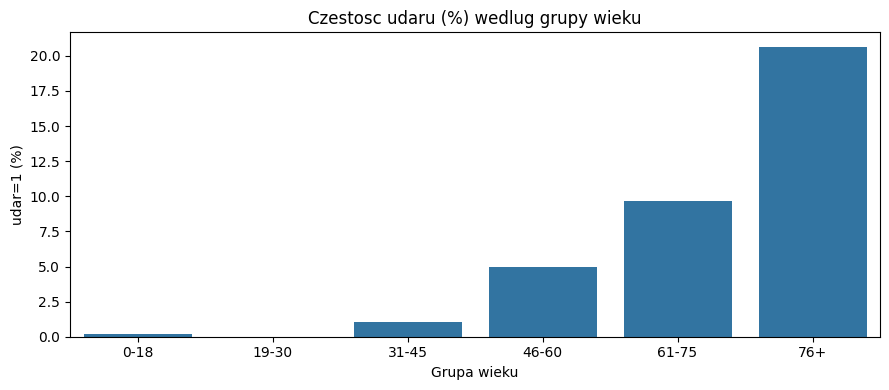

In [72]:
age_bins = [0, 18, 30, 45, 60, 75, 100]
age_labels = ["0-18", "19-30", "31-45", "46-60", "61-75", "76+"]

df_age = df.copy()
df_age["przedzial_wieku"] = pd.cut(
    df_age["age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True,
    right=True,
)

age_stats = df_age.groupby("przedzial_wieku", observed=False).agg(
    liczebnosc=("stroke", "count"),
    odsetek_udaru_proc=("stroke", lambda s: s.mean() * 100),
)

display(age_stats.round(2))

plt.figure(figsize=(9, 4))
sns.barplot(x=age_stats.index.astype(str), y=age_stats["odsetek_udaru_proc"].values)
plt.title("Czestosc udaru (%) wedlug grupy wieku")
plt.xlabel("Grupa wieku")
plt.ylabel("udar=1 (%)")
plt.tight_layout()
plt.show()

### Wnioski z EDA

- Zmienna celu `stroke` jest silnie niezbalansowana (klasa pozytywna to niewielki odsetek danych), dlatego sama accuracy nie bedzie wystarczajaca do oceny modelu.
- Braki `bmi` niosa informacje: dla `bmi_missing=1` odsetek `stroke=1` jest wyraznie wyzszy niz dla `bmi_missing=0` (ok. `19.9%` vs `4.26%`).
- Wiek ma silny zwiazek z ryzykiem: wraz ze wzrostem grupy wiekowej rosnie odsetek `stroke=1`.
- Dla cech kategorycznych (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) widoczne sa roznice miedzy grupami, wiec warto zachowac, np. przez użycie OneHotEncoding.

## 6. Podział danych i metodologia

- Kodowanie zmiennych kategorycznych
- Skalowanie zmiennych numerycznych
- Podział na zbiory: treningowy / walidacyjny / testowy.
- Strategia walidacji (np. cross-validation).
- Metryki oceny (np. accuracy, precision, recall, F1, ROC-AUC).
- Kryteria wyboru modelu końcowego.

In [73]:
X = df.drop(columns=["stroke"]).copy()
y = df["stroke"].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=False)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

**Dlaczego używamy SMOTE?**

Zmienna celu `stroke` jest silnie niezbalansowana (klasa pozytywna jest rzadka), co może powodować, że model będzie faworyzował klasę `0`.

SMOTE (Synthetic Minority Oversampling Technique) tworzy syntetyczne przykłady klasy mniejszościowej tylko na zbiorze treningowym, dzięki czemu model ma lepszą szansę nauczyć się wzorców dla `stroke=1` i nie ignorować przypadków pozytywnych.

Ważne: SMOTE stosujemy wyłącznie na danych treningowych (`X_train`, `y_train`), a zbiór testowy pozostaje bez zmian, aby ocena modelu była uczciwa.

In [74]:
print("Przed SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=67)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nPo SMOTE:")
print(y_train_smote.value_counts())

print("X_train_smote:", X_train_smote.shape)
print("X_test:", X_test.shape)
print("y_train_smote:", y_train_smote.shape)
print("y_test:", y_test.shape)

Przed SMOTE:
stroke
0    3889
1     199
Name: count, dtype: int64

Po SMOTE:
stroke
0    3889
1    3889
Name: count, dtype: int64
X_train_smote: (7778, 21)
X_test: (1022, 21)
y_train_smote: (7778,)
y_test: (1022,)


## 7. Trenowanie modeli

- Model bazowy (baseline).
- Modele porównawcze.
- Strojenie hiperparametrów.
- Tabela porównawcza wyników.

## 8. Ewaluacja modelu końcowego

- Macierz pomyłek i interpretacja.
- Klasyfikacja błędów.
- Analiza cech ważnych dla predykcji.
- Ograniczenia modelu.

## 9. Wnioski i dalsze kroki

- Podsumowanie najważniejszych rezultatów.
- Odpowiedź na pytanie badawcze.
- Propozycje ulepszeń.
- Pomysły na dalszą pracę.